# ML Predictive Maintenance
### Data Ingestion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv("../data/predictive_maintenance.csv")
df[df['Failure Type']!='No Failure']

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,Power Failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,Power Failure
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,Tool Wear Failure
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,Overstrain Failure
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,Overstrain Failure
...,...,...,...,...,...,...,...,...,...,...
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1,Tool Wear Failure
9764,9765,L56944,L,298.5,309.5,1294,66.7,12,1,Power Failure
9822,9823,L57002,L,298.5,309.4,1360,60.9,187,1,Overstrain Failure
9830,9831,L57010,L,298.3,309.3,1337,56.1,206,1,Overstrain Failure


In [4]:
print(df.describe())
df.columns

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]        Target  
count            10000.000000  10000.000000     10000.000000  10000.000000  
mean              1538.776100     39.986910       107.951000      0.033900  
std                179.284096      9.968934        63.654147      0.180981  
min               1168.000000      3.800000         0.000000      0.000000  
25

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='str')

array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Target'}>, <Axes: >, <Axes: >]],
      dtype=object)

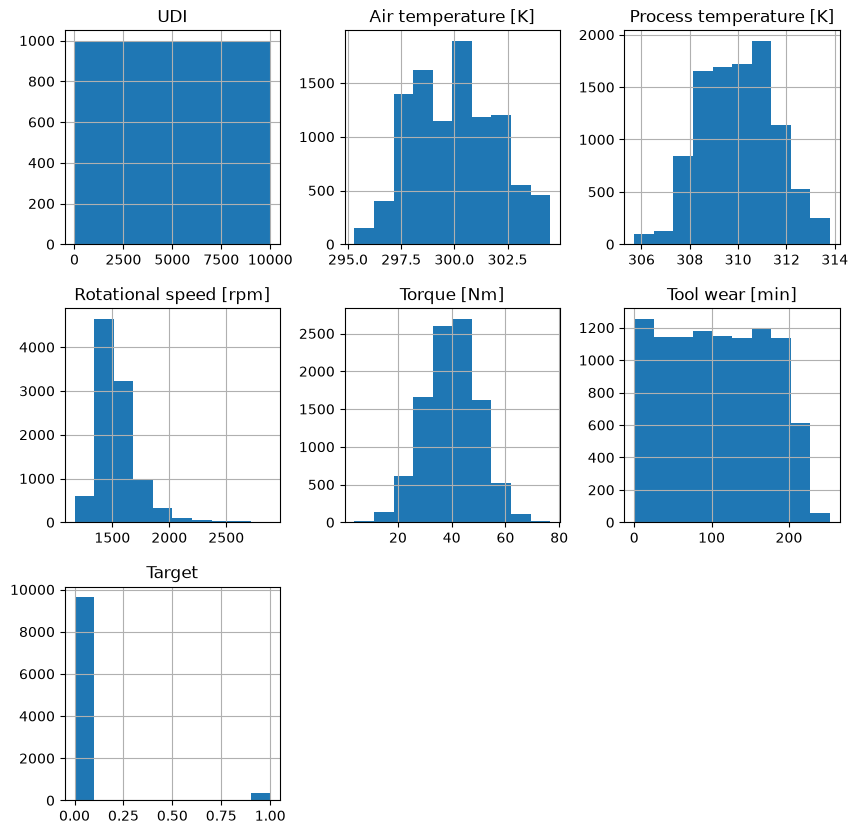

In [5]:
df.hist(figsize=(10, 10))

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [7]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

### Outlier Detection: Boxplot

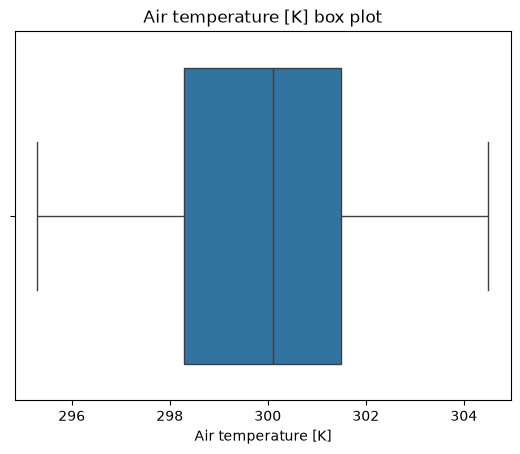

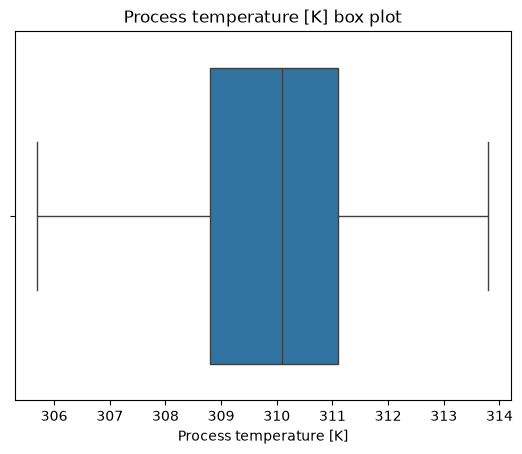

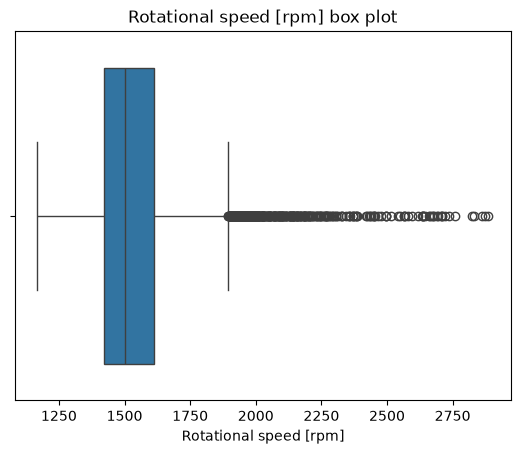

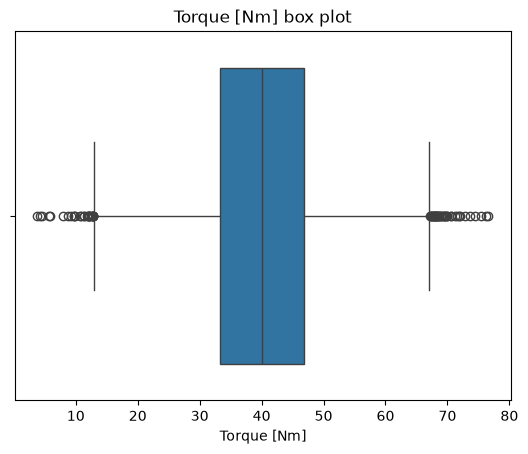

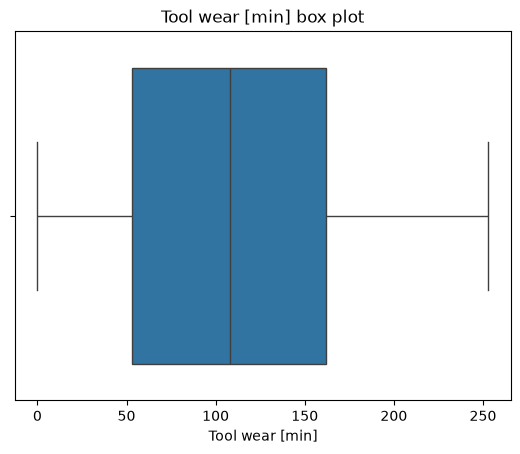

In [8]:
sensor_cols = ['Air temperature [K]','Process temperature [K]', 
               'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]']

for col in sensor_cols:
       sns.boxplot(x=df[col])
       plt.title(f"{col} box plot")
       plt.show()

## Feature Engineering

In [9]:
df['Type'].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [10]:
df['Type'] = df["Type"].map({"L":0, "M":1, "H":3})

feature_cols = ['Type', 'Air temperature [K]','Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]']

xfeatures = df[feature_cols]
ylabel = df['Failure Type']

In [11]:
#Split
X_train, X_test, y_train, y_test = train_test_split(xfeatures,ylabel, test_size=0.25, train_size=0.75)

#Load and build models
def load_models(classifier, xtrain, ytrain):
    classifier.fit(xtrain, ytrain)
    return classifier

In [12]:
randf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls = load_models(randf, X_train, y_train)

logReg = LogisticRegression(random_state=42)
logReg_cls = load_models(logReg, X_train, y_train)

c:\Virtual World\ml_predictive_maintenance\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
#SCORES
rf_socre = rf_cls.score(X_test,y_test)
log_score = logReg_cls.score(X_test, y_test)
print(f"Random Forest Classifier Score: {rf_socre}\nLogistic Regression Score: {log_score}")

#Accuracy
y_predict = rf_cls.predict(X_test)
print("\nRandom Forest Classifier:")
print(classification_report(y_test, y_predict))

y_pred = logReg_cls.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_predict))


Random Forest Classifier Score: 0.9792
Logistic Regression Score: 0.966

Random Forest Classifier:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.90      0.61      0.73        31
              No Failure       0.98      1.00      0.99      2414
      Overstrain Failure       0.89      0.44      0.59        18
           Power Failure       0.78      0.82      0.80        17
         Random Failures       0.00      0.00      0.00         8
       Tool Wear Failure       0.00      0.00      0.00        12

                accuracy                           0.98      2500
               macro avg       0.59      0.48      0.52      2500
            weighted avg       0.97      0.98      0.97      2500

Logistic Regression:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.90      0.61      0.73        31
              No Failure       0.98      1.00      0.99      2414
      Overstrain F

c:\Virtual World\ml_predictive_maintenance\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Virtual World\ml_predictive_maintenance\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Virtual World\ml_predictive_maintenance\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

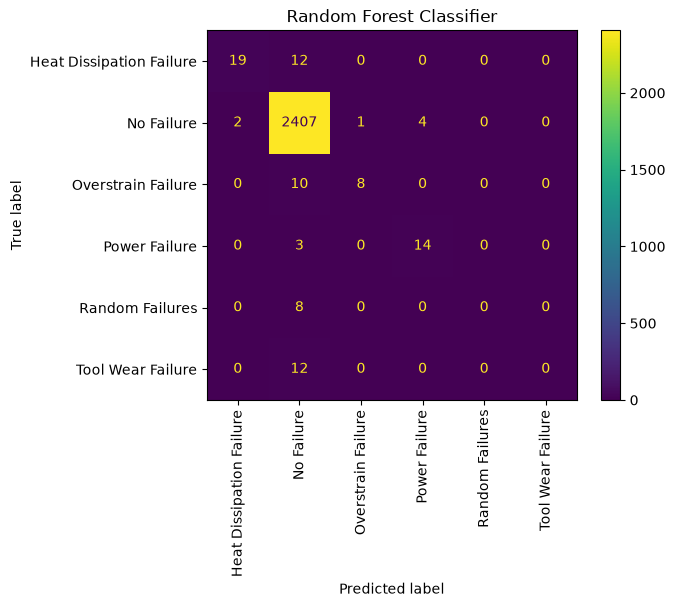

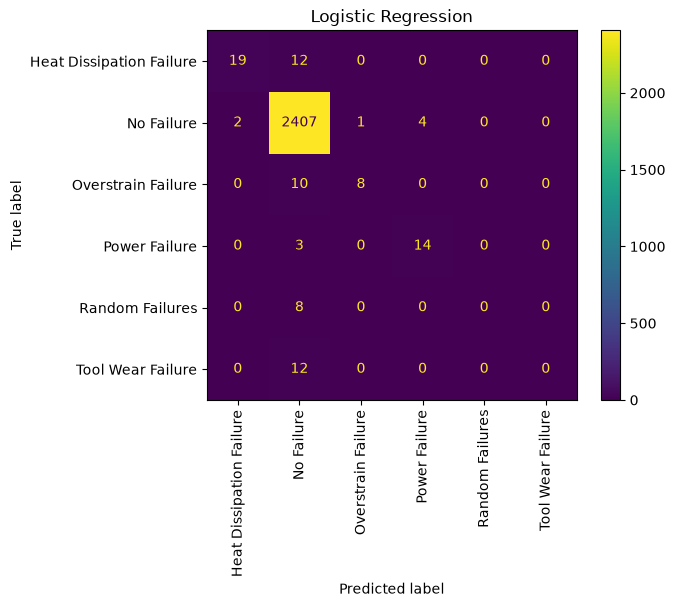

In [14]:
rf_cm = confusion_matrix(y_test,y_predict, labels=rf_cls.classes_)
disp_rf =ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_cls.classes_)

log_cm = confusion_matrix(y_test,y_predict, labels=logReg_cls.classes_)
disp_log =ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=logReg_cls.classes_)

disp_rf.plot()
plt.title("Random Forest Classifier")
plt.xticks(rotation=90)

disp_log.plot()
plt.title("Logistic Regression")
plt.xticks(rotation=90)
plt.show()

### Test

In [15]:
test01 = np.array([2,299,310,2861,5,143]).reshape(1, -1)
test02 = np.array([1,298.4,308.2,1282,60.7,216]).reshape(1,-1)
sample_test = X_test.iloc[0]
print(f"LR Prediction: {logReg_cls.predict(test01)}")
print(f"RF Prediction: {rf_cls.predict(test02)}")

LR Prediction: ['Power Failure']
RF Prediction: ['Overstrain Failure']


c:\Virtual World\ml_predictive_maintenance\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Virtual World\ml_predictive_maintenance\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Model Interpretion


SyntaxError: source code string cannot contain null bytes (<string>)